# Fermi-Hubbard Figure 4-style benchmark

This notebook builds the 1D Fermi-Hubbard dynamics used in arXiv:2605.04025 with a pair-interleaved Jordan-Wigner map. The paper's Figure 4 benchmarks L=60 hardware occupations against TDVP. Here we recreate the same operator-dynamics workflow with Pauli propagation using plain coefficient and weight truncation: the default run is a small exact-checkable system, and the final cell shows how to switch to the paper-scale L=60 setup.

Paper Figure 4 parameters: L=60 sites, N=120 spin orbitals, U/t_h=-2, dt=0.2, T=6, and RMSE across all 2L occupations n_{i,sigma}.

In [1]:
using Pkg

# Avoid GUI plot windows when the notebook is executed as a script.
if !isinteractive()
    ENV["GKSwstype"] = get(ENV, "GKSwstype", "100")
end

# Robust activation from either repo root or examples/.
project_root = if isfile(joinpath(pwd(), "Project.toml")) && isdir(joinpath(pwd(), "src"))
    pwd()
else
    abspath(joinpath(pwd(), ".."))
end

try
    Pkg.activate(project_root)
catch err
    @warn "Could not activate project; continuing with the current Julia environment" exception=(err, catch_backtrace())
end

using PauliOperators
using LinearAlgebra
using Plots
using Plots.PlotMeasures
using Printf
using Statistics

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


## Jordan-Wigner operators

The creation operator below follows the convention in the prompt:

a_f^dagger = 1/2 (X_f - iY_f) Z_{f-1} ... Z_1.

The notebook uses this to build hopping terms c_i^dagger c_j + h.c.; number operators are built directly as n_f = (I - Z_f)/2.

In [2]:
"""
    jordan_wigner(f::Integer, N::Integer)

Jordan-Wigner image of the fermionic creation operator a_f^dagger on N spin orbitals.
"""
function jordan_wigner(f::Integer, N::Integer)
    1 <= f <= N || throw(ArgumentError("f must satisfy 1 <= f <= N (got f=$f, N=$N)"))
    z_pre = Int128(2)^(f - 1) - Int128(1)
    x_f = Int128(2)^(f - 1)
    out = PauliSum(N, ComplexF64)
    out[PauliBasis{N}(z_pre, x_f)] = 0.5 + 0.0im
    out[PauliBasis{N}(z_pre | x_f, x_f)] = -0.5im
    return out
end

function number_operator(f::Integer, N::Integer)
    1 <= f <= N || throw(ArgumentError("f must satisfy 1 <= f <= N (got f=$f, N=$N)"))
    return 0.5 * PauliSum(Pauli(N)) - 0.5 * PauliSum(Pauli(N; Z=[f]))
end

number_operator (generic function with 1 method)

## Pair-interleaved Fermi-Hubbard model

The paper uses the pair-interleaved ordering

{c_0 down, c_0 up, c_1 up, c_1 down, c_2 down, c_2 up, ...}.

The helper below uses 1-based Julia site indices while keeping that same physical ordering.

In [3]:
const SPINS = (:up, :down)

function orbital_index(site::Integer, spin::Symbol)
    site >= 1 || throw(ArgumentError("site must be 1-based and positive"))
    spin in SPINS || throw(ArgumentError("spin must be :up or :down"))
    base = 2 * site - 1
    if isodd(site)
        return spin == :down ? base : base + 1
    else
        return spin == :up ? base : base + 1
    end
end

function orbital_label(f::Integer, L::Integer)
    for site in 1:L, spin in SPINS
        if orbital_index(site, spin) == f
            return "site $(site - 1), $(spin)"
        end
    end
    return "orbital $f"
end

function neel_bits(L::Integer; vacancy_site=nothing)
    bits = zeros(Int, 2 * L)
    for site in 1:L
        if vacancy_site !== nothing && site == vacancy_site
            continue
        end
        spin = isodd(site) ? :down : :up
        bits[orbital_index(site, spin)] = 1
    end
    return bits
end

function fermi_hubbard_1d(L::Integer; th::Real=1.0, U::Real=-2.0, mu::Real=0.0)
    N = 2 * L
    H = PauliSum(N, ComplexF64)

    # -th * sum_{<i,j>,sigma} (c_i^dagger c_j + h.c.)
    for site in 1:(L - 1), spin in SPINS
        f = orbital_index(site, spin)
        g = orbital_index(site + 1, spin)
        adag_f = jordan_wigner(f, N)
        adag_g = jordan_wigner(g, N)
        hopping = adag_f * adag_g' + adag_g * adag_f'
        H += -th * hopping
    end

    # U n_up n_down - mu (n_up + n_down), dropping the identity energy shift.
    for site in 1:L
        f_up = orbital_index(site, :up)
        f_dn = orbital_index(site, :down)
        H += (mu / 2 - U / 4) * PauliSum(Pauli(N; Z=[f_up]))
        H += (mu / 2 - U / 4) * PauliSum(Pauli(N; Z=[f_dn]))
        H += (U / 4) * PauliSum(Pauli(N; Z=[f_up, f_dn]))
    end

    coeff_clip!(H, 1e-14)
    return H
end

fermi_hubbard_1d (generic function with 1 method)

## Exact and Pauli-propagation runners

For small systems we compute an exact dense reference. For larger systems, keep `RUN_EXACT = false` and use the Pauli propagation curves directly.

In [4]:
function occupations_from_state(psiv::AbstractVector, N::Integer)
    occ = zeros(Float64, N)
    for (idx, amp) in enumerate(psiv)
        prob = abs2(amp)
        prob <= eps(Float64) && continue
        state = idx - 1
        for f in 1:N
            if ((state >> (f - 1)) & 1) == 1
                occ[f] += prob
            end
        end
    end
    return occ
end

function exact_occupation_curves(H::PauliSum{N}, psi::Ket{N}, times::AbstractVector) where {N}
    N <= 20 || error("Dense exact reference is only intended for small N; got N=$N")
    Hm = Hermitian(Matrix(H))
    F = eigen(Hm)
    lambda, V = F.values, F.vectors

    psiv = zeros(ComplexF64, Int(2)^N)
    psiv[Int(psi.v) + 1] = 1.0
    c0 = V' * psiv

    occ = zeros(Float64, length(times), N)
    for (k, t) in enumerate(times)
        psit = V * (cis.(-t .* lambda) .* c0)
        occ[k, :] = occupations_from_state(psit, N)
    end
    return occ
end

function pauli_occupation_curve(H::PauliSum{N,T}, f::Integer, psi::Ket{N},
                                times::AbstractVector, dt::Real,
                                truncation::TruncationStrategy; order::Int=2) where {N,T}
    generators, angles = trotterize(H, dt; n_trotter=1, order=order)
    Ot = number_operator(f, N)
    ev = zeros(Float64, length(times))
    n_terms = zeros(Int, length(times))

    ev[1] = real(expectation_value(Ot, psi))
    n_terms[1] = length(Ot)

    for step in 2:length(times)
        Ot = evolve(Ot, generators, angles; truncation=truncation)
        ev[step] = real(expectation_value(Ot, psi))
        n_terms[step] = length(Ot)
    end

    return ev, n_terms
end

function run_pauli_occupations(H::PauliSum{N}, psi::Ket{N}, times, dt, config;
                               orbitals=collect(1:N), order::Int=2) where {N}
    occ = zeros(Float64, length(times), length(orbitals))
    terms = zeros(Int, length(times), length(orbitals))

    runtime = @elapsed begin
        for (j, f) in enumerate(orbitals)
            ev, n_terms = pauli_occupation_curve(H, f, psi, times, dt, config.strategy(); order=order)
            occ[:, j] = ev
            terms[:, j] = n_terms
        end
    end

    return (label=config.label, family=config.family, parameter=config.parameter, cutoff=config.cutoff,
            occ=occ, terms=terms, runtime=runtime, orbitals=orbitals)
end

function rmse_by_time(occ::AbstractMatrix, ref::AbstractMatrix, orbitals::AbstractVector{<:Integer})
    diffs = occ .- ref[:, orbitals]
    return vec(sqrt.(mean(abs2, diffs; dims=2)))
end

rmse_by_time (generic function with 1 method)

## Truncation configs

This notebook compares the two basic truncation strategies directly: `CoeffTruncation(eps)` and `WeightTruncation(k)`.

In [5]:
function coeff_config(eps::Real)
    return (
        family="Coeff",
        label="Coeff eps=$(eps)",
        parameter=:eps,
        cutoff=Float64(eps),
        strategy=() -> CoeffTruncation(Float64(eps)),
    )
end

function weight_config(k::Integer)
    return (
        family="Weight",
        label="Weight k=$(k)",
        parameter=:k,
        cutoff=Int(k),
        strategy=() -> WeightTruncation(Int(k)),
    )
end

weight_config (generic function with 1 method)

## Benchmark setup

The default `L = 5` run is intentionally small so exact reference curves are available. To run the paper-scale operator propagation, use the guarded L=60 cell at the end.

In [11]:
L = 5
N = 2 * L
th = 1.0
U = -2.0
mu = 0.0
dt = 0.2
T_max = 6.0
times = collect(0.0:dt:T_max)

# Figure 4 appears to use the plain Neel state. Set this true for the vacancy-defect variant.
use_vacancy = false
vacancy_site = cld(L, 2)
psi = Ket(neel_bits(L; vacancy_site=use_vacancy ? vacancy_site : nothing))
H = fermi_hubbard_1d(L; th=th, U=U, mu=mu)

RUN_EXACT = N <= 12
RUN_ALL_ORBITALS = N <= 16
orbitals_to_run = RUN_ALL_ORBITALS ? collect(1:N) : [orbital_index(cld(L, 2), :up)]
coeff_thresholds = L <= 8 ? [1e-3, 5e-4, 1e-4] : [1e-3, 5e-4, 1e-4]
weight_cutoffs = L <= 8 ? [2, 3, 4] : [8, 10, 12, 14, 16]

@printf("L=%d sites, N=%d spin orbitals, U/th=%.2f, mu=%.2f, dt=%.2f, T=%.2f\n", L, N, U / th, mu, dt, T_max)
@printf("Hamiltonian terms: %d, occupations to propagate: %d\n", length(H), length(orbitals_to_run))
display(psi)

|1010101010>

L=5 sites, N=10 spin orbitals, U/th=-2.00, mu=0.00, dt=0.20, T=6.00
Hamiltonian terms: 31, occupations to propagate: 10


In [12]:
exact_occ = nothing
exact_runtime = NaN

if RUN_EXACT
    @printf("Computing dense exact occupation reference...\n")
    exact_runtime = @elapsed exact_occ = exact_occupation_curves(H, psi, times)
    @printf("Exact reference complete in %.2fs.\n", exact_runtime)
end

configs = Any[]
append!(configs, [coeff_config(eps) for eps in coeff_thresholds])
append!(configs, [weight_config(k) for k in weight_cutoffs])

results = Any[]
for (i, config) in enumerate(configs)
    @printf("[%2d/%2d] %-12s", i, length(configs), config.label)
    result = run_pauli_occupations(H, psi, times, dt, config; orbitals=orbitals_to_run, order=2)
    if RUN_EXACT && RUN_ALL_ORBITALS
        result = merge(result, (rmse=rmse_by_time(result.occ, exact_occ, orbitals_to_run),))
        @printf(" runtime=%7.2fs final_RMSE=%.3e peak_terms=%d\n",
                result.runtime, last(result.rmse), maximum(result.terms))
    else
        @printf(" runtime=%7.2fs peak_terms=%d\n", result.runtime, maximum(result.terms))
    end
    push!(results, result)
end

Computing dense exact occupation reference...
Exact reference complete in 0.63s.
[ 1/ 6] Coeff eps=0.001 runtime=   2.88s final_RMSE=9.394e-02 peak_terms=3208
[ 2/ 6] Coeff eps=0.0005 runtime=   9.97s final_RMSE=3.796e-02 peak_terms=9947
[ 3/ 6] Coeff eps=0.0001 runtime=  82.16s final_RMSE=2.802e-02 peak_terms=86059
[ 4/ 6] Weight k=2   runtime=   0.00s final_RMSE=1.720e-01 peak_terms=7
[ 5/ 6] Weight k=3   runtime=   0.10s final_RMSE=9.716e-02 peak_terms=177
[ 6/ 6] Weight k=4   runtime=   3.55s final_RMSE=5.101e-02 peak_terms=2482


## Summary table

In [13]:
hasfield(nt, name::Symbol) = name in propertynames(nt)

summary_rows = [(
    family=r.family,
    label=r.label,
    parameter=r.parameter,
    cutoff=r.cutoff,
    final_rmse=hasfield(r, :rmse) ? last(r.rmse) : NaN,
    max_rmse=hasfield(r, :rmse) ? maximum(r.rmse) : NaN,
    peak_terms=maximum(r.terms),
    mean_terms=round(mean(r.terms); digits=1),
    runtime_s=round(r.runtime; digits=2)
) for r in results]

display(sort(summary_rows; by=row -> (row.family, row.cutoff)))

6-element Vector{NamedTuple{(:family, :label, :parameter, :cutoff, :final_rmse, :max_rmse, :peak_terms, :mean_terms, :runtime_s)}}:
 (family = "Coeff", label = "Coeff eps=0.0001", parameter = :eps, cutoff = 0.0001, final_rmse = 0.02801549240611657, max_rmse = 0.06932241503409255, peak_terms = 86059, mean_terms = 40757.2, runtime_s = 82.16)
 (family = "Coeff", label = "Coeff eps=0.0005", parameter = :eps, cutoff = 0.0005, final_rmse = 0.037956349920231426, max_rmse = 0.10542342434879157, peak_terms = 9947, mean_terms = 4933.8, runtime_s = 9.97)
 (family = "Coeff", label = "Coeff eps=0.001", parameter = :eps, cutoff = 0.001, final_rmse = 0.09394039898270777, max_rmse = 0.1050957727132592, peak_terms = 3208, mean_terms = 1553.3, runtime_s = 2.88)
 (family = "Weight", label = "Weight k=2", parameter = :k, cutoff = 2, final_rmse = 0.1719741851450965, max_rmse = 0.3784484199545409, peak_terms = 7, mean_terms = 5.9, runtime_s = 0.0)
 (family = "Weight", label = "Weight k=3", parameter = :k, c

## Figure 4-style plot

Panel (a) is the representative occupation trace, panel (b) zooms late-time dynamics, panel (c) shows RMSE across all propagated spin orbitals, and panel (d) shows measured notebook wall-clock time. This is not hardware/TDVP data; it is the same benchmark shape applied to Pauli propagation.

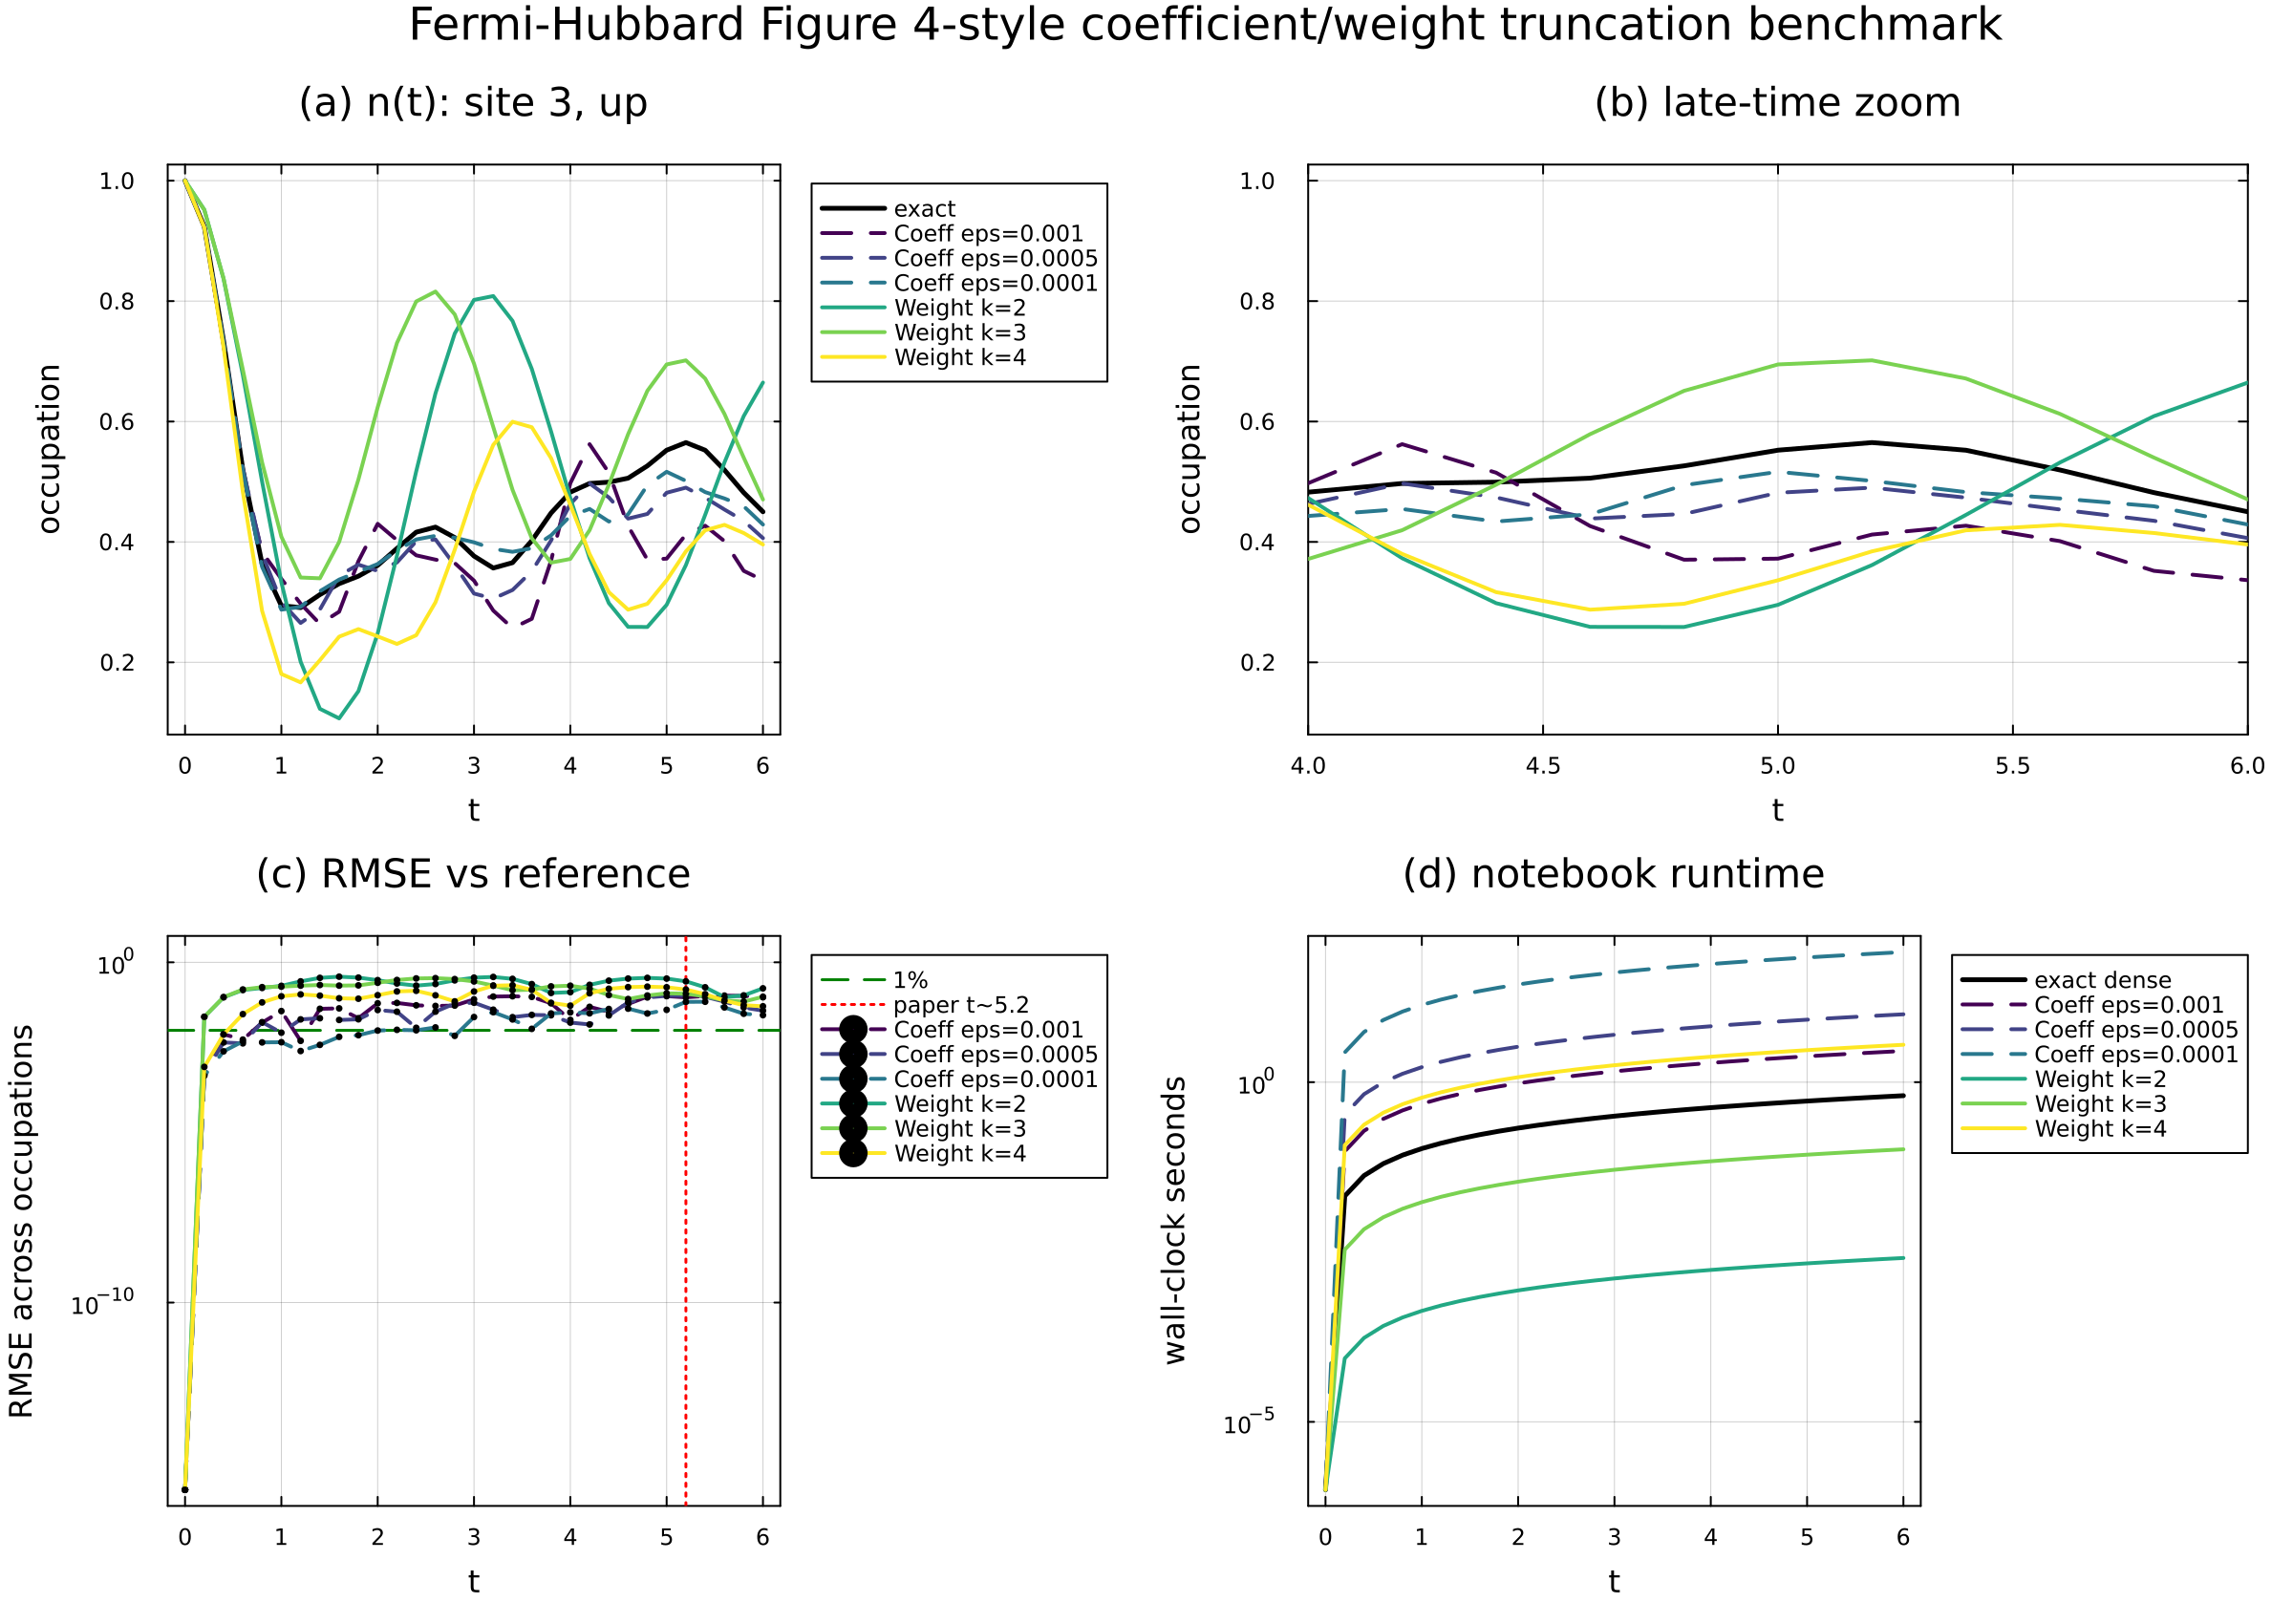

In [14]:
function result_color(i, n)
    return cgrad(:viridis, n, categorical=true)[i]
end

function result_style(r)
    return r.family == "Coeff" ? :dash : :solid
end

representative_site = L >= 47 ? 47 : cld(3 * L, 4)
representative_orbital = orbital_index(representative_site, :up)
rep_col = findfirst(==(representative_orbital), orbitals_to_run)
if rep_col === nothing
    representative_orbital = first(orbitals_to_run)
    rep_col = 1
end
rep_label = orbital_label(representative_orbital, L)

p_a = plot(xlabel="t", ylabel="occupation", title="(a) n(t): $(rep_label)",
           legend=:outertopright, framestyle=:box, margin=4mm, size=(560, 380), dpi=200)
if RUN_EXACT && exact_occ !== nothing
    plot!(p_a, times, exact_occ[:, representative_orbital], label="exact", color=:black, lw=2.5)
end
for (i, r) in enumerate(results)
    plot!(p_a, times, r.occ[:, rep_col], label=r.label, color=result_color(i, length(results)),
          lw=2, ls=result_style(r))
end

zoom_start = max(0.0, T_max - 2.0)
p_b = plot(xlabel="t", ylabel="occupation", title="(b) late-time zoom",
           xlims=(zoom_start, T_max), legend=false, framestyle=:box, margin=4mm,
           size=(560, 380), dpi=200)
if RUN_EXACT && exact_occ !== nothing
    plot!(p_b, times, exact_occ[:, representative_orbital], label="exact", color=:black, lw=2.5)
end
for (i, r) in enumerate(results)
    plot!(p_b, times, r.occ[:, rep_col], label=r.label, color=result_color(i, length(results)),
          lw=2, ls=result_style(r))
end

p_c = plot(xlabel="t", ylabel="RMSE across occupations", title="(c) RMSE vs reference",
           yscale=:log10, legend=:outertopright, framestyle=:box, margin=4mm,
           size=(560, 380), dpi=200)
if all(hasfield(r, :rmse) for r in results)
    hline!(p_c, [0.01], label="1%", color=:green, ls=:dash, lw=1.5)
    vline!(p_c, [5.2], label="paper t~5.2", color=:red, ls=:dot, lw=1.5)
    for (i, r) in enumerate(results)
        plot!(p_c, times, max.(r.rmse, 1e-16), label=r.label,
              color=result_color(i, length(results)), lw=2, ls=result_style(r), marker=:circle, ms=1)
    end
else
    annotate!(p_c, 0.5, 0.5, text("No exact reference for this system size", :center, 10))
end

p_d = plot(xlabel="t", ylabel="wall-clock seconds", title="(d) notebook runtime",
           yscale=:log10, legend=:outertopright, framestyle=:box, margin=4mm,
           size=(560, 380), dpi=200)
if RUN_EXACT && isfinite(exact_runtime)
    exact_cumulative = max.(exact_runtime .* (0:(length(times)-1)) ./ max(length(times)-1, 1), 1e-6)
    plot!(p_d, times, exact_cumulative, label="exact dense", color=:black, lw=2.5)
end
for (i, r) in enumerate(results)
    cumulative = max.(r.runtime .* (0:(length(times)-1)) ./ max(length(times)-1, 1), 1e-6)
    plot!(p_d, times, cumulative, label=r.label, color=result_color(i, length(results)),
          lw=2, ls=result_style(r))
end

fig4_style = plot(p_a, p_b, p_c, p_d, layout=(2, 2), size=(1200, 850), dpi=200,
                  plot_title="Fermi-Hubbard Figure 4-style coefficient/weight truncation benchmark")
display(fig4_style)

## Optional paper-scale selected-orbital run

Set `RUN_PAPER_SCALE = true` to build the L=60 Hamiltonian and propagate selected occupation operators with selected coefficient thresholds and weight cutoffs. This does not compute TDVP or exact reference data.

In [ ]:
RUN_PAPER_SCALE = true

if RUN_PAPER_SCALE
    L_big = 60
    N_big = 2 * L_big
    H_big = fermi_hubbard_1d(L_big; th=1.0, U=-2.0, mu=0.0)
    psi_big = Ket(neel_bits(L_big; vacancy_site=nothing))
    times_big = collect(0.0:0.2:6.0)

    # Paper Figure 4 panel (a) uses site i=46, spin up. The paper index is zero-based.
    target_orbitals = [orbital_index(47, :up)]
    big_coeff_thresholds = [1e-4]
    big_weight_cutoffs = [16]
    big_configs = Any[]
    append!(big_configs, [coeff_config(eps) for eps in big_coeff_thresholds])
    append!(big_configs, [weight_config(k) for k in big_weight_cutoffs])

    big_results = Any[]
    for (i, config) in enumerate(big_configs)
        @printf("[paper-scale %d/%d] %s\n", i, length(big_configs), config.label)
        push!(big_results, run_pauli_occupations(H_big, psi_big, times_big, 0.2, config;
                                                orbitals=target_orbitals, order=2))
    end

    p_big = plot(xlabel="t", ylabel="occupation", title="L=60 selected orbital: site 46, up",
                 legend=:outertopright, framestyle=:box, margin=5mm, size=(850, 520), dpi=200)
    for (i, r) in enumerate(big_results)
        plot!(p_big, times_big, r.occ[:, 1], label=r.label, color=result_color(i, length(big_results)), lw=2)
    end
    display(p_big)
end